In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, Normalizer, MinMaxScaler

In [ ]:
# global data definition
DATASET_PATH = '/home/sgeraci/Desktop/datasets'

TRAIN_DATASET_PATH = '/home/sgeraci/slu/inet-hynn/pysrc/flows_test.csv'
# EVALU_DATASET_PATH = f'{DATASET_PATH}/UNSW-NB15/UNSW_NB15_testing-set.csv'

In [ ]:
def data_preprocess(rawdata: pd.DataFrame, spec_dict):
    categorical_features_values, continuous_features_values, list_drop = spec_dict.values()
    data = pd.concat([rawdata])
    data.drop(list_drop,axis=1,inplace=True, errors='ignore')
    
    # convert cat values to integer and limit categorical values
    cols_cat = data.select_dtypes(exclude=[np.number]).columns
    if cols_cat.any():
        for feat in cols_cat: 
            if data[feat].nunique()>categorical_features_values:
                data[feat] = np.where(data[feat].isin(data[feat].value_counts().head(categorical_features_values).index), data[feat], '-')
            
            data[feat] = data[feat].astype('category')
            data[feat] = data[feat].cat.codes

    og_samples = data[data.columns[:-1]]

    # clamping continuous values
    data_num = data.select_dtypes(include=[np.number])
    for feat in data_num.columns:
        if data_num[feat].max()>10*data_num[feat].median() :
            data[feat] = np.where(data[feat]<data[feat].quantile(0.95), data[feat], data[feat].quantile(0.95))


    # unskew data applying log
    # data_num = data.select_dtypes(include=[np.number])
    # for feature in data_num.columns:
    #     if data_num[feature].nunique()>continuous_features_values:
    #         if data_num[feature].min()==0:
    #             data[feature] = np.log(data[feature]+1)
    #         else:
    #             data[feature] = np.log(data[feature])


    # from bool features to int
    # bool_cols = samples.select_dtypes(include=bool).columns
    # if(len(bool_cols)):
    #     samples[bool_cols] = samples[bool_cols].astype(int)
    
    # split features and labels
    samples = data[data.columns[:-1]]
    labels = data[data.columns[-1]]

    # standardize float column
    # scaler = StandardScaler()
    # data_num = samples.select_dtypes(include=np.number)
    # samples[data_num.columns] = scaler.fit_transform(samples[data_num.columns])

    # standardize float column
    # normalizer = Normalizer()
    # data_num = samples.select_dtypes(include=np.number)
    # samples[data_num.columns] = normalizer.fit_transform(samples[data_num.columns])

    return og_samples, samples, labels

### Data import and cleaning 

In [3]:
dict = {
    'categorical_features_values': 6,
    'continuous_features_values': 50,
    'list_drop': [
        'id',
        'attack_cat'
    ]
}

data_tr = pd.read_csv(TRAIN_DATASET_PATH, delimiter=',')

In [4]:
(data_tr['label'] == 1).sum()
# (data_tr['label'] == 0).sum()

16319

In [ ]:
og_X, X, Y = data_preprocess(data_tr, dict)

assert  og_X.columns.equals(X.columns)

/tmp/ipykernel_235801/804169432.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples[data_num.columns] = normalizer.fit_transform(samples[data_num.columns])


### FEATURE PLOT

In [ ]:
res_folder='metric_plots/features_results'
for feat in og_X.columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(og_X[feat].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[0].set_title(f'rawdata avg {og_X[feat].mean():.4f} mdn {og_X[feat].median():.6f}')
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(X[feat].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[1].set_title(f'preprocessed avg {X[feat].mean():.4f} mdn {X[feat].median():.6f}')
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    fig.suptitle(f'Feature: {feat}', fontsize=16)
     
    res_subfolder = 'float_feats' if og_X[feat].dtype == np.float64 else 'int_feats'
    # plt.savefig(f'{res_folder}/{res_subfolder}/{feat}')
    plt.show()
    fig.clear()

plt.clf()

In [ ]:
def print_correlation_matrix(data: pd.DataFrame):
    cols_cat = data.select_dtypes(exclude=[np.number]).columns
    if cols_cat.any():
        for col in cols_cat:
            data[col] = data[col].astype('category')
            data[col] = data[col].cat.codes
    corr = data.corr()
    
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.matshow(corr, cmap='inferno')
    n = range(0, corr.columns.size)
    ax.set_xticks(n)
    ax.set_yticks(n)
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    ax.xaxis.set_ticks_position('bottom')
    plt.tight_layout()
    plt.show()

    return corr

raw_corr  = print_correlation_matrix(og_X)
proc_corr = print_correlation_matrix(X)

### Feature importance

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

X_tr, X_val, Y_tr, Y_val = train_test_split(og_X, Y, random_state=42)
feature_names = X_tr.columns
forest = RandomForestClassifier(random_state=0)
forest.fit(X_tr, Y_tr)
res = permutation_importance(forest, X_val, Y_val, n_repeats=10, random_state=42, n_jobs=2)
forest_importances = pd.Series(res.importances_mean, index=feature_names).sort_values(ascending=False)

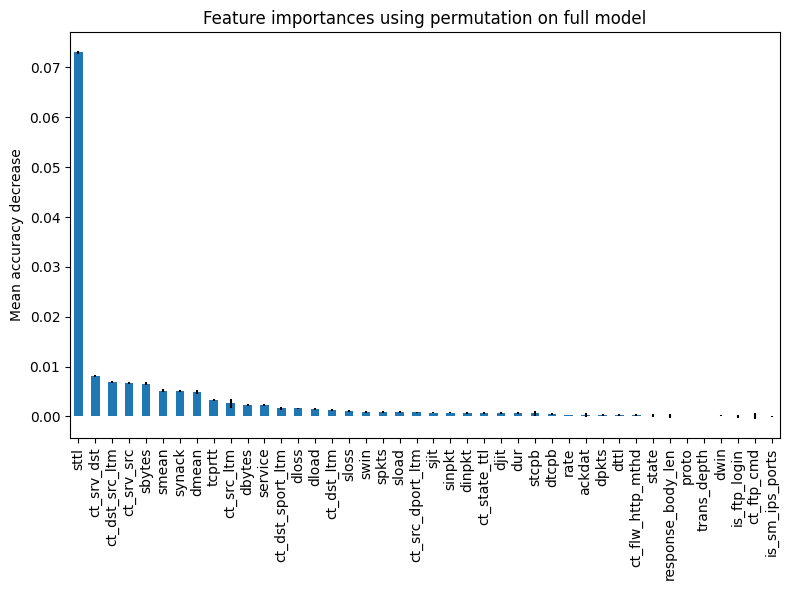

['sttl', 'ct_srv_dst', 'ct_dst_src_ltm', 'ct_srv_src', 'sbytes', 'smean', 'synack', 'dmean', 'tcprtt', 'ct_src_ltm', 'dbytes', 'service', 'ct_dst_sport_ltm', 'dloss', 'dload', 'ct_dst_ltm', 'sloss', 'swin']


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
forest_importances.plot.bar(yerr=res.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
print(forest_importances.keys()[:20])
plt.show()

selected_features = list(forest_importances.keys()[:18])
print(selected_features)

In [ ]:
X_tr, X_val, Y_tr, Y_val = train_test_split(X, Y, random_state=42)
feature_names = X_tr.columns
forest = RandomForestClassifier(random_state=0)
forest.fit(X_tr, Y_tr)
res = permutation_importance(forest, X_val, Y_val, n_repeats=10, random_state=42, n_jobs=2)
forest_importances = pd.Series(res.importances_mean, index=feature_names).sort_values(ascending=False)

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
forest_importances.plot.bar(yerr=res.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
print(forest_importances.keys()[:20])
plt.show()

In [ ]:
dt = pd.read_csv('/home/sgeraci/Desktop/datasets/UNSW-NB15/UNSW_NB15_training-set.csv', delimiter=',')
dt[dt['dttl']==0].head(20)

,proto,sttl,dttl
0,tcp,252,254
1,tcp,62,252
2,tcp,62,252
3,tcp,62,252
4,tcp,254,252
5,tcp,254,252
6,tcp,254,252
7,tcp,254,252
8,tcp,254,252
9,tcp,254,252
